# Baseline Determination — calibration of the $u$-axis

## Why this notebook exists

The science results in **notebook 05** — the radio Sun's diameter and the EW position of any active region — both rest on a *calibrated projected baseline*

$$|u_{\mathrm{sky}}(h)| = \frac{1}{\lambda}\sqrt{(b_{\mathrm{ew}}\cos\delta\cos h)^2 + (b_{\mathrm{ns}}\cos L)^2},$$

evaluated at every observed hour angle ([TMS3] §4 for the underlying $(u,v,w)$ machinery). The diameter measurement converts the location of a Bessel null in $|u|$ into an angular radius via $R = j_{1,k}/(2\pi |u|_k)$, so a 1 % error in $|u|$ becomes a 1 % error in the diameter, which is roughly $0.3'$. The sunspot phase localization recovers $\Delta\alpha = -(2\pi)^{-1}\,d\arg(V)/du$, so an error in the slope of the $u$-axis becomes an error in the spot offset.

This notebook is therefore **calibration**, not science. Its purpose is twofold:

1. **Validate the lidar prior** ($b_{\mathrm{ew}} = 15.17 \pm 0.30$ m, $b_{\mathrm{ns}} = 1.36 \pm 0.30$ m) using the fringe data themselves. The lidar number is precise enough that this is essentially a sanity check, but the cross-check answers **scientific question 3** of the lab roadmap (§01) — *can we measure our own array geometry from the sky alone?* The five independent fitters used here also illustrate the textbook techniques (FFT, phase-slope, lag-spectrum, NLS, brute-force grid search) and let us quantify which ones converge on the right answer with which error bars.

2. **Hand off a single calibrated $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$** to notebook 05, where it is consumed by `extract_fringe_envelope` and `localize_sunspot_phase`.

If a fitter disagrees with the lidar prior by more than ~30 cm, that is a diagnostic worth pursuing *before* trusting the science notebook. If they all agree, the calibration is solid and you can move on. The §4.7 summary table encodes this as a per-method `dEW/sigma`, `dNS/sigma` column; the §4.8 systematic budget concludes that the realistic uncertainty on the adopted baseline is **the 10 cm lidar floor**.

What follows: Method 1 (FFT) → Method 2 (phase slope) → Method 3 (lag spectrum) → Method 4 (NLS) → Method 5 (grid search) → §4.7 summary + lidar comparison → §4.8 systematic budget → fringe-model overlay (validation of the adopted baseline against the data).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult, GridSearchResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    grid_search_baseline,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 23–55 captures
  Chip 1: window range 23–35 captures
  Chip 2: window range 21–39 captures
Bad channels:       [0, 256, 512, 768]


In [4]:
# --- Apply per-chip gain correction from notebook 02a ---
# 02a measured a ~10% multiplicative gain step between chip 0 and chip 2.
# The vector `chip_gains_measured` was saved to a sidecar pickle file; we load
# it here and divide each chip's visibilities by its gain so that all chips
# sit on a single amplitude scale before the baseline fits. The baseline fits
# are formally insensitive to an overall amplitude, but the separable
# least-squares projection can still be biased by inconsistent per-chip
# amplitudes, and notebook 05 (which needs a correctly-calibrated envelope)
# relies on this same correction. Running the correction in nb 04 keeps the
# two notebooks consistent.
import pickle as _pkl
from utils import apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains_measured = np.array(_cal["chip_gains_measured"])
    SIGMA_V_PER_CAPTURE = float(_cal["sigma_V_per_capture"])
    print(f"Loaded chip gains from 02a sidecar: {chip_gains_measured}")
    print(f"Per-capture sigma_V = {SIGMA_V_PER_CAPTURE:.4g}")
else:
    chip_gains_measured = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
    SIGMA_V_PER_CAPTURE = 0.01
    print(f"[warning] 02a sidecar not found — falling back to default chip gains "
          f"{chip_gains_measured}. Run notebook 02a first to refresh the sidecar.")

# Apply the correction in place on the DC-corrected visibility. Do it as a
# new variable (corr_dc_gc) so diagnostic code that still references corr_dc
# can compare before/after.
corr_dc_gc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains_measured)

# From here on, the science code paths use corr_dc_gc, but we keep corr_dc
# as a reference for diagnostics that want to see the uncorrected spectrum.
# Redirect the alias so the existing downstream fit code picks up the
# corrected data automatically.
corr_dc = corr_dc_gc

print("Chip-gain correction applied: all chips now share the chip-0 amplitude scale.")

# Part IV: Baseline Determination

We determine both baseline components $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$ using seven independent methods, applied to all chips pooled. The seven methods follow [TMS3] Ch. 10–12 for the standard textbook techniques and [Bevington & Robinson 2003] / [AY121-FitNotes] for the $\chi^2$ / covariance machinery.

## 4.1 Method 1: FFT in the x-coordinate
*(Spatial FFT; recovers $b_{\mathrm{ew}}$ only.)*

The visibility phase is $\phi = 2\pi(b_{\mathrm{ew}}/\lambda)\,x$ where $x = \cos\delta\,\sin h$. In this coordinate the fringe is a pure sinusoid with spatial frequency $f_x = b_{\mathrm{ew}}/\lambda$, so taking the FFT of the visibility in uniformly-sampled $x$ and finding the peak directly gives the baseline:

$$\boxed{b_{\mathrm{ew}} = |f_{x,\mathrm{peak}}| \times \frac{c}{\nu}.}$$

> **Limitation:** The $x$-coordinate linearisation absorbs the $\cos h$ term from $b_{\mathrm{ns}}$ — this method **only measures $b_{\mathrm{ew}}$** and returns $b_{\mathrm{ns}} = 0$ with infinite uncertainty. Methods 2–5 below recover both components.

In [5]:
# --- Method 1: FFT baseline (all chips pooled, broadband) ---
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)

fft_result, fft_per_ch = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if fft_result is not None:
    print(f"FFT:  B_EW = {fft_result.b_ew_m:.4f} +/- {fft_result.b_ew_err_m:.4f} m  "
          f"({fft_result.n_points} channels, "
          f"median SNR = {fft_result.metadata.get('median_snr', 0):.1f})")

FFT:  B_EW = 15.5429 +/- 0.0023 m  (285 channels, median SNR = 133.5)


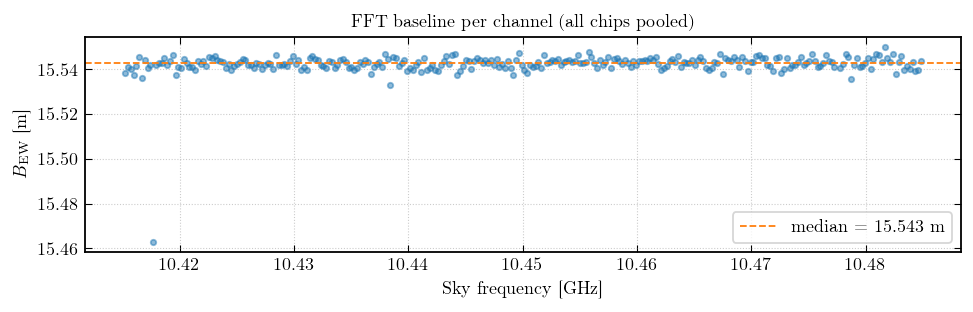

In [6]:
# --- FFT baseline: per-channel distribution ---
valid_ch = np.isfinite(fft_per_ch["b_ew_m"])

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.5))
ax.scatter(F_SKY_GHZ[valid_ch], fft_per_ch["b_ew_m"][valid_ch], s=SS_FINE,
           color="C0", alpha=0.5)
if fft_result is not None:
    ax.axhline(fft_result.b_ew_m, color="C1", lw=LW_LIGHT,
               ls="--", label=f"median = {fft_result.b_ew_m:.3f} m")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel(r"$B_{\rm EW}$ [m]")
ax.set_title("FFT baseline per channel (all chips pooled)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

## 4.1a Method 1a: Temporal STFT — fringe-frequency fit
*(Lab-manual prescribed method: [AY121-Lab3] §"Local Fringe Frequency" and Week 1 task; STFT windowing [Harris78]; fringe-frequency equation also in [TMS3] §4.)*

This is the method **explicitly prescribed** in the lab manual.  Week 1 task: *"Each person calculates Fourier power spectra of the Sun data, calculating the range of expected local fringe frequencies … and comparing the observed spectra with these expectations."*

### Derivation

The band-averaged complex visibility is a slowly-chirped sinusoid:
$$V(t) \approx R\,e^{i\phi_0}\,\exp\!\bigl[i\,2\pi f_f(h(t))\,t\bigr]$$
where $f_f(h)$ drifts smoothly from $\sim 0$ near the horizon to $\sim 0.038$ Hz at transit.  Within a short window around $h_0$ the fringe is approximately sinusoidal, so the Short-Time Fourier Transform (STFT) — Hann-windowed, zero-padded ([Harris78]; [Oppenheim] §8.6) — gives a peak at the local fringe frequency $\hat{f}_{f,i}$.

**Fringe-frequency equation** ([AY121-Lab3] eq. `fringefreq`, boxed; same as [TMS3] §4.1):
$$\boxed{\frac{f_{f,Hz}}{\omega_\oplus} = \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\,\cos h - \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta\,\sin h}$$

This is **linear** in $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$, so collecting measured $\hat{f}_{f,i}$ at hour angles $h_i$ gives a straightforward OLS problem.  The design matrix is:
$$X_i = \left[\frac{\omega_\oplus\cos\delta_i\cos h_i}{\lambda},\; -\frac{\omega_\oplus\sin L\cos\delta_i\sin h_i}{\lambda}\right]$$
and we solve $\hat{f}_{f,i} = X_i\,[b_{\mathrm{ew}},\,b_{\mathrm{ns}}]^T$ by OLS.

> **Limitation:** $b_{\mathrm{ns}}$ is poorly constrained near transit where $\sin h \approx 0$ — the NS regressor vanishes.  Windows near Bessel nulls (low fringe amplitude → low SNR) are automatically masked.  Compare to Methods 2–4 for the full constraint on both components.


In [7]:
# --- Method 1a: STFT fringe-frequency fit (lab-manual prescription) ---
# Implementation subtleties that matter for this dataset:
#   1. STFT is run *per chip* via chip_slices= so windows never straddle an
#      inter-chip dead-time gap.
#   2. `stft_fringe_frequency` interpolates each chip onto a uniform HA grid
#      before the FFT (the NCH capture cadence has up to ~40% intra-chip
#      jitter, which would otherwise bias the FFT frequency axis).
#   3. **Prior-constrained peak search.** A baseline prior (the lidar
#      measurement, b_ew_prior_m / b_ns_prior_m) is supplied. At each
#      window centre the algorithm computes the predicted f_f from that
#      prior and then restricts the FFT peak search to a band of
#      ±search_tol_hz around the prediction. This is essential at low SNR:
#      near the Bessel nulls of the disk envelope the fringe collapses
#      below noise and the unconstrained peak finder otherwise locks onto
#      a sidelobe several mHz away. With the prior gate the per-window
#      measurement remains honest across the entire HA range, not just
#      near transit. (The fit is still a least-squares fit of f_f vs HA;
#      the prior only narrows the *search range*, not the *fit*. The
#      recovered baseline is whatever the data prefers inside the gate.)
#   4. The fit uses SNR-weighted least squares with iterative 3-sigma
#      outlier rejection (`stft_baseline_from_ff`).
#
# Parameter choice: window=64, step=16 — small enough to span the full
# HA range with many windows; min_snr=3 is permissive because the prior
# gate is what is doing the basin selection; search_tol_hz=1 mHz is wide
# enough to absorb a ~10% baseline-prior error on f_f.
from utils import stft_baseline, stft_fringe_frequency, stft_baseline_from_ff

stft_result = stft_baseline(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
    chip_slices=chip_slices,
    window_size=64, step_size=16, min_snr=3.0,
    b_ew_prior_m=NOMINAL_B_EW_M,
    b_ns_prior_m=NOMINAL_B_NS_M,
    search_tol_hz=1.0e-3,    # ±1 mHz around the lidar-prior prediction
)
if stft_result is not None:
    print(f"STFT:  B_EW = {stft_result.b_ew_m:.4f} +/- {stft_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {stft_result.b_ns_m:+.4f} +/- {stft_result.b_ns_err_m:.4f} m  "
          f"({stft_result.n_points} windows kept after sigma-clip)")
else:
    print("STFT: no valid windows (check data length vs window_size)")


STFT:  B_EW = 15.1444 +/- 0.0207 m,  B_NS = +1.4212 +/- 0.0194 m  (73 windows kept after sigma-clip)


/tmp/ipykernel_1715897/2784417437.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


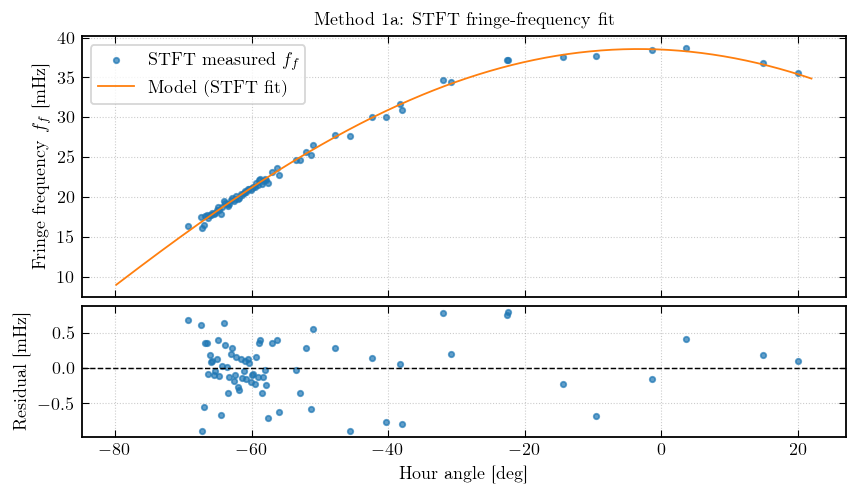

STFT residual RMS: 0.394 mHz (1.02% of peak f_f)


In [8]:
# --- Method 1a: STFT diagnostic — measured fringe frequency vs model ---
if stft_result is not None and stft_result.metadata.get("ha_centers") is not None:
    ha_c    = stft_result.metadata["ha_centers"]
    ff_meas = stft_result.metadata["ff_hz_measured"]
    ff_mod  = stft_result.metadata["ff_hz_model"]              # full length (NaN outside fit)
    valid_mask = stft_result.metadata.get(
        "valid_mask",
        np.isfinite(ff_meas) & np.isfinite(ff_mod),
    )

    # Smooth model curve using the fitted baseline for display only
    ha_smooth = np.linspace(ha_rad_arr.min(), ha_rad_arr.max(), 500)
    lam_mid = C_LIGHT_MS / band_center_hz
    ff_model_smooth = OMEGA_EARTH_RAD_S * (
        (stft_result.b_ew_m / lam_mid) * np.cos(dec_rad_mean) * np.cos(ha_smooth)
        - (stft_result.b_ns_m / lam_mid) * np.sin(np.deg2rad(NCH_LAT_DEG))
          * np.cos(dec_rad_mean) * np.sin(ha_smooth)
    )

    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

    axes[0].scatter(
        np.rad2deg(ha_c[valid_mask]), ff_meas[valid_mask] * 1e3,
        c="C0", s=SS_FINE, alpha=0.7, label="STFT measured $f_f$",
    )
    axes[0].plot(np.rad2deg(ha_smooth), ff_model_smooth * 1e3,
                 color="C1", lw=LW_LIGHT, label="Model (STFT fit)")
    axes[0].set_ylabel(r"Fringe frequency $f_f$ [mHz]")
    axes[0].legend(fontsize=TICK_SIZE)
    axes[0].set_title("Method 1a: STFT fringe-frequency fit", fontsize=TICK_SIZE)

    resid_hz = ff_meas[valid_mask] - ff_mod[valid_mask]
    axes[1].scatter(np.rad2deg(ha_c[valid_mask]), resid_hz * 1e3,
                    c="C0", s=SS_FINE, alpha=0.7)
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].set_xlabel(r"Hour angle [deg]")
    axes[1].set_ylabel(r"Residual [mHz]")

    fig.tight_layout()
    plt.show()

    rms_mhz = float(np.nanstd(resid_hz) * 1e3)
    print(f"STFT residual RMS: {rms_mhz:.3f} mHz "
          f"({100 * rms_mhz / (np.nanmax(np.abs(ff_meas)) * 1e3):.2f}% of peak f_f)")


## 4.2 Method 2: Phase slope against physical regressors  
*(Standard linear-regression interferometric calibration; [TMS3] §10.1. Covariance from $(\mathbf{X}^T\mathbf{X})^{-1}$, [Bevington & Robinson 2003] / [AY121-FitNotes].)*

The complex visibility has phase $\phi = \arg(V) = 2\pi\nu\tau'_g + \phi_c$, so the unwrapped phase is

$$\phi_i = \frac{2\pi\nu}{c}\bigl[b_{\mathrm{ew}}\cos\delta_i\,\sin h_i + b_{\mathrm{ns}}\sin L\,\cos\delta_i\,\cos h_i\bigr] + \phi_c.$$

The per-capture declination $\delta_i$ is folded directly into the design matrix
$$\mathbf{X} = \bigl[\cos\delta_i\sin h_i,\;\sin L\,\cos\delta_i\cos h_i,\;1\bigr],$$
so the fit coefficients $A$ and $B$ already absorb $\cos\delta$ and $\sin L$, giving

$$\boxed{b_{\mathrm{ew}} = \frac{A\,c}{2\pi\nu}, \qquad b_{\mathrm{ns}} = \frac{B\,c}{2\pi\nu}.}$$

> **Note:** Because $\cos\delta_i$ is a regressor column (not a divisor applied after fitting), no division by $\cos\delta$ is needed in the recovery. The sign of $b_{\mathrm{ew}}$ is degenerate with the cable phase, so only $|b_{\mathrm{ew}}|$ is reported; $b_{\mathrm{ns}}$ keeps its sign.

In [9]:
# --- Method 2: Phase slope (all chips pooled, broadband) ---
ps_result, ps_per_ch = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if ps_result is not None:
    ns = f"B_NS = {ps_result.b_ns_m:.4f} +/- {ps_result.b_ns_err_m:.4f} m" if np.isfinite(ps_result.b_ns_err_m) else "B_NS unconstrained"
    print(f"Phase slope:  B_EW = {ps_result.b_ew_m:.4f} +/- {ps_result.b_ew_err_m:.4f} m,  "
          f"{ns}  ({ps_result.n_points} channels)")

Phase slope:  B_EW = 14.5602 +/- 0.0089 m,  B_NS = -1.7690 +/- 0.0161 m  (285 channels)


## 4.3 Method 3: Lag-spectrum delay  
*(Standard delay-calibration approach in connected-element correlators such as the VLA; [TMS3] §10.2.)*

The inverse FFT of the cross-correlation spectrum transforms frequency channels to a lag (delay) axis. The lag peak gives the geometric delay $\tau$ directly in nanoseconds. The fit uses the physical regressors (with per-capture declination) matching the delay model:

$$\tau_i = b_{\mathrm{ew}}\,\frac{\cos\delta_i\,\sin h_i}{c} + b_{\mathrm{ns}}\,\frac{\sin L\,\cos\delta_i\,\cos h_i}{c} + \tau_{\mathrm{inst}}$$

i.e. design matrix $[\cos\delta_i\sin h_i,\;\sin L\cos\delta_i\cos h_i,\;1]$ with the delay in nanoseconds, so coefficients $A$ (ns) and $B$ (ns) recover baselines directly as

$$b_{\mathrm{ew}} = A \cdot 10^{-9}\cdot c, \qquad b_{\mathrm{ns}} = B \cdot 10^{-9}\cdot c,$$

and the instrumental delay from the intercept $\tau_{\mathrm{inst}}$. This method is frequency-independent — all channels contribute to a single delay estimate per capture.

In [10]:
# --- Method 3: Lag-spectrum delay (all chips pooled) ---
lag_result = lag_delay_baseline_series(
    ha_rad_arr, corr_dc, dec_rad_arr, DF_HZ,
    bad_channels=BAD_CHANNELS,
)
if lag_result is not None:
    print(f"Lag delay:  B_EW = {lag_result.b_ew_m:.4f} +/- {lag_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {lag_result.b_ns_m:.4f} +/- {lag_result.b_ns_err_m:.4f} m  "
          f"(tau_inst = {lag_result.metadata['tau_inst_ns']:.2f} ns, "
          f"median SNR = {lag_result.metadata['median_snr']:.1f})")

Lag delay:  B_EW = 15.1348 +/- 0.0096 m,  B_NS = 1.5449 +/- 0.0295 m  (tau_inst = 47.11 ns, median SNR = 89.9)


## 4.4 Lag delay diagnostic: tau vs sin(h) and cos(h)  
*(The $\sin h$ / $\cos h$ regressors come straight from the geometric delay derived in §1.1, [TMS3] §4.1.)*

We visualise the lag delay as a function of $\sin h$ for the longest chip. The linear relationship validates the geometric-delay model, and the fit coefficients give both $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$.

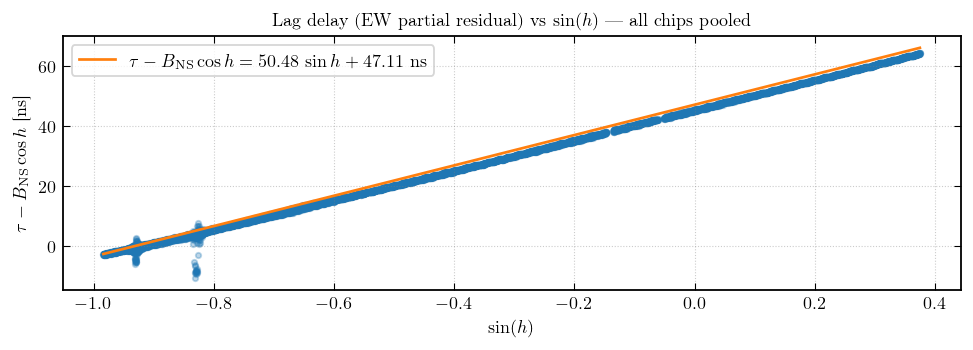

In [11]:
# --- Lag delay diagnostic plot (all chips pooled) ---
if lag_result is not None:
    sin_h = np.sin(ha_rad_arr)
    cos_h = np.cos(ha_rad_arr)
    tau_ns = lag_result.metadata["tau_ns"]
    valid = np.isfinite(tau_ns)

    A_ns = lag_result.metadata["A_ns_per_sinh"]
    B_ns = lag_result.metadata["B_ns_per_cosh"]
    intercept = lag_result.metadata["tau_inst_ns"]

    # Partial residual: subtract the cos(h) (NS) contribution so that the
    # scatter shows only the EW/sin(h) component.  The overlay then reduces
    # to a straight line A_ns * sin(h) + tau_inst, which can be compared
    # directly to the points.
    #   Full model: tau = A*sin(h) + B*cos(h) + tau_inst
    #   Subtract B*cos(h): tau - B*cos(h) = A*sin(h) + tau_inst
    tau_partial = tau_ns - B_ns * cos_h

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
    ax.scatter(sin_h[valid], tau_partial[valid], s=SS_FINE, color="C0", alpha=0.3)

    # Overlay: A_ns * sin(h) + tau_inst — an exact description of the plotted points
    x_fit = np.linspace(sin_h[valid].min(), sin_h[valid].max(), 100)
    ax.plot(x_fit, A_ns * x_fit + intercept, lw=LW_STANDARD, color="C1",
            label=rf"$\tau - B_{{\rm NS}}\cos h = {A_ns:.2f}\,\sin h + {intercept:.2f}$ ns")

    ax.set_xlabel(r"$\sin(h)$")
    ax.set_ylabel(r"$\tau - B_{\rm NS}\cos h$ [ns]")
    ax.set_title("Lag delay (EW partial residual) vs $\\sin(h)$ — all chips pooled", fontsize=TICK_SIZE)
    ax.legend(fontsize=TICK_SIZE)
    fig.tight_layout()
    plt.show()

## 4.5 Method 4: Nonlinear least-squares complex fringe fit  
*(Variable-projection / separable nonlinear least-squares: [Golub & Pereyra 1973, *SIAM J. Numer. Anal.* **10**, 413]. Levenberg-Marquardt back-end via `scipy.optimize.least_squares`, [Virtanen et al. 2020, *Nat. Methods* **17**, 261].)*

This method fits the full fringe equation directly to the complex visibility:

$$V_i = (A + iC)\cos\psi_i + (B + iD)\sin\psi_i,$$
$$\psi_i = 2\pi\!\left[\frac{b_{\mathrm{ew}}}{\lambda}\cos\delta_i\,\sin h_i + \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta_i\,\cos h_i\right].$$

Per-capture declination $\delta_i$ enters $\psi_i$ at every step. The linear parameters $(A, B, C, D)$ are solved analytically at each step; the nonlinear parameters $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ are optimised via Levenberg-Marquardt, seeded from the phase-slope result.

In [12]:
# --- Method 4: NLS fringe fit (all chips pooled, broadband) ---
nls_result, nls_per_ch = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_result is not None:
    print(f"NLS:  B_EW = {nls_result.b_ew_m:.4f} +/- {nls_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_result.b_ns_m:.4f} +/- {nls_result.b_ns_err_m:.4f} m  "
          f"({nls_result.n_points} channels)")

NLS:  B_EW = 14.5834 +/- 0.0777 m,  B_NS = -1.6744 +/- 0.2961 m  (285 channels)


## 4.5a Method 4a: Nonlinear least-squares — real fringe fit
*(Lab-manual prescribed equation: [AY121-Lab3] eq.* `fringeresponse` *(boxed); [Ryle52]; same separable NLS structure as Method 4: [Golub73]; [Virtanen20].)*

### Derivation

The lab manual's fringe-response equation ([AY121-Lab3] eq. `fringeresponse`, boxed) is **real-valued**:
$$\boxed{F(h_s) = A\cos(2\pi\nu\tau_g') + B\sin(2\pi\nu\tau_g')}$$
where $A \equiv \cos(2\pi\nu\tau_c')$ and $B \equiv -\sin(2\pi\nu\tau_c')$ absorb the instrumental cable phase.  The observable is the power output of the adding interferometer ([Ryle52]):
$$\hat{F}_i = \mathrm{Re}[V_i]$$

With $\psi_i = 2\pi\nu\tau_g'(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ depending nonlinearly on the baseline, we use the same **separable NLS** structure as Method 4 ([Golub73]):
- **Nonlinear step:** Levenberg-Marquardt on $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ via `scipy.optimize.least_squares` ([Virtanen20]).
- **Linear step (analytical):** At each nonlinear iterate, $A$ and $B$ are solved from the $2\times2$ normal equations $[X^TX]\,[A,B]^T = X^T\hat{F}$ where $X = [\cos\psi_i, \sin\psi_i]$.

The residual vector has **$N$ points** (vs $2N$ for Method 4 which uses both Re and Im), so the formal uncertainties are larger by roughly $\sqrt{2}$ when signal-to-noise is equal.

> **Comparison with Method 4.** If Method 4a and Method 4 return the same central values but Method 4a has larger error bars, this validates (i) that the imaginary channel adds information without bias, and (ii) that the digital correlator output is correctly interpreted as a complex cross-correlation.


In [13]:
# --- Method 4a: NLS real fringe fit (lab-manual eq. fringeresponse) ---
from utils import nls_real_baseline_broadband

nls_real_result, nls_real_per_ch = nls_real_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_real_result is not None:
    print(f"NLS-real:  B_EW = {nls_real_result.b_ew_m:.4f} +/- {nls_real_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_real_result.b_ns_m:.4f} +/- {nls_real_result.b_ns_err_m:.4f} m  "
          f"({nls_real_result.n_points} channels)")
    if nls_result is not None:
        print(f"  cf NLS-complex: B_EW = {nls_result.b_ew_m:.4f} ± {nls_result.b_ew_err_m:.4f} m  "
              f"(σ ratio = {nls_real_result.b_ew_err_m / nls_result.b_ew_err_m:.2f}, expected ~√2 = {2**0.5:.2f})")
else:
    print("NLS-real: no result")


NLS-real:  B_EW = 14.5811 +/- 0.0922 m,  B_NS = -1.6921 +/- 0.2846 m  (285 channels)
  cf NLS-complex: B_EW = 14.5834 ± 0.0777 m  (σ ratio = 1.19, expected ~√2 = 1.41)


## 4.6 Method 5: Brute-force grid search

The brute-force technique formalised in the AY 121 fitting notes ([AY121-FitNotes]; ultimate textbook source [Bevington & Robinson 2003] §11) evaluates the cost function on a 2-D grid over $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$, solving $(A, B, C, D)$ analytically at each grid point. Unlike gradient-based methods, this is guaranteed to find the **global** minimum within the search range and produces a $\chi^2$ map that reveals the structure of the cost surface — degeneracies, sidelobes, and confidence contours.

Grid search (ch 655, 10.450 GHz):
  Seeded from NLS: Q_ew = 508.3, Q_ns = -58.4
  B_EW = 15.2395 +/- 0.0000 m
  B_NS = 1.2357 +/- 0.0008 m
  S2_min = 245.8415,  chi2_nu = 0.014948,  dof = 16446
  Curvature matrix [alpha]:
    [[        inf  0.        ]
 [ 0.         21.25056651]]
  Covariance matrix (sigma^2 * [alpha]^-1):
    [[0.         0.        ]
 [0.         0.00070344]]


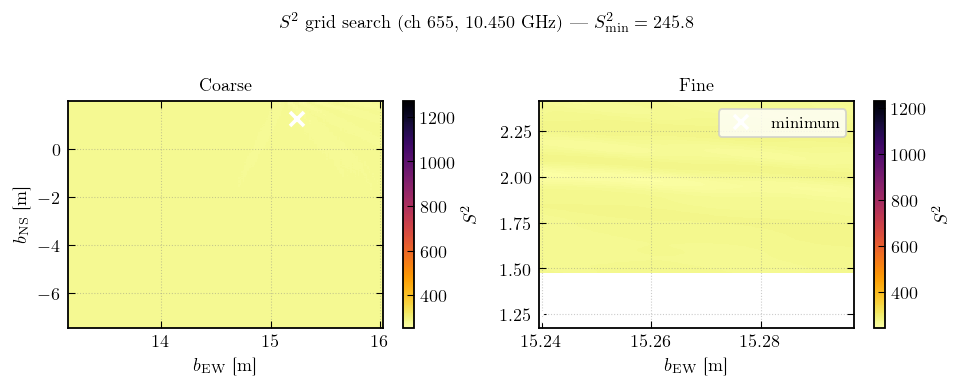

In [14]:
# --- Method 5: Brute-force grid search on a representative channel ---
# Seed the search range from the NLS fringe fit result
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

if nls_result is not None:
    q_ew_center = nls_result.b_ew_m / lam
    q_ns_center = nls_result.b_ns_m / lam
else:
    q_ew_center = NOMINAL_B_EW_M / lam
    q_ns_center = 0.0

gs = grid_search_baseline(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=300,
    q_ew_range=(q_ew_center - 50.0, q_ew_center + 50.0),
    q_ns_range=(q_ns_center - 100.0, q_ns_center + 100.0),
)

if gs is not None:
    cos_dec = np.cos(dec_rad_mean)
    sin_lat = np.sin(np.deg2rad(NCH_LAT_DEG))
    dof = max(1, 2 * gs.n_points - 6)

    print(f"Grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  Seeded from NLS: Q_ew = {q_ew_center:.1f}, Q_ns = {q_ns_center:.1f}")
    print(f"  B_EW = {gs.b_ew_m:.4f} +/- {gs.b_ew_err_m:.4f} m")
    print(f"  B_NS = {gs.b_ns_m:.4f} +/- {gs.b_ns_err_m:.4f} m")
    print(f"  S2_min = {gs.S2_min:.4f},  chi2_nu = {gs.S2_min / dof:.6f},  dof = {dof}")
    print(f"  Curvature matrix [alpha]:\n    {gs.alpha_matrix}")
    print(f"  Covariance matrix (sigma^2 * [alpha]^-1):\n    {gs.covariance_matrix}")

    # --- Side-by-side: coarse and fine S² maps ---
    fig, (ax_c, ax_f) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.38))

    # (a) Coarse grid
    b_ew_c = gs.Q_ew_coarse * lam / cos_dec
    b_ns_c = gs.Q_ns_coarse * lam / (sin_lat * cos_dec)
    S2_c_min = np.nanmin(gs.S2_coarse[np.isfinite(gs.S2_coarse)])

    im_c = ax_c.pcolormesh(
        b_ew_c, b_ns_c, gs.S2_coarse,
        cmap="inferno_r", shading="auto",
        vmin=S2_c_min, vmax=S2_c_min * 5,
    )
    ax_c.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2)
    ax_c.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_c.set_ylabel(r"$b_{\rm NS}$ [m]")
    ax_c.set_title("Coarse", fontsize=TICK_SIZE)
    fig.colorbar(im_c, ax=ax_c, label=r"$S^2$")

    # (b) Fine grid
    b_ew_f = gs.Q_ew_grid * lam / cos_dec
    b_ns_f = gs.Q_ns_grid * lam / (sin_lat * cos_dec)

    im_f = ax_f.pcolormesh(
        b_ew_f, b_ns_f, gs.S2_map,
        cmap="inferno_r", shading="auto",
        vmin=gs.S2_min, vmax=gs.S2_min * 5,
    )
    ax_f.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2, label="minimum")
    ax_f.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_f.set_title("Fine", fontsize=TICK_SIZE)
    ax_f.legend(fontsize=TICK_SIZE - 1)
    fig.colorbar(im_f, ax=ax_f, label=r"$S^2$")

    fig.suptitle(rf"$S^2$ grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz)"
                 rf" — $S^2_{{\min}} = {gs.S2_min:.1f}$",
                 fontsize=TICK_SIZE, y=1.02)
    fig.tight_layout()
    plt.show()

## 4.6a Lab-prescribed step 1: 1-D brute-force sweep of $\mathcal{S}^2$ vs $Q_{\mathrm{ew}}$

Section §8.4.3 of the AY 121 lab manual and the 2017 fitting notes prescribe a three-step procedure for extracting the baseline:

1. **1-D sweep** over $Q_{\mathrm{ew}} = b_{\mathrm{ew}}/\lambda$ with $Q_{\mathrm{ns}}=0$, tabulating $\mathcal{S}^2(Q_{\mathrm{ew}})$, to verify that the minimum is not a sidelobe of the fringe-frequency aliases.
2. **2-D sweep** $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$ (§4.6 above) to refine the minimum jointly.
3. **Curvature matrix** $[\alpha]$ extracted from the 2-D $\mathcal{S}^2$ grid → covariance $[\alpha]^{-1}$ → uncertainties.

The existing `grid_search_baseline` in §4.6 already does steps 2 and 3 (it builds a coarse-then-fine 2-D grid and extracts the curvature matrix numerically). Here we add the missing step 1 as an explicit 1-D sweep so that the report can show the classical "sharp minimum inside a forest of sidelobes" plot that every reader of the lab manual will expect.

1-D sweep: 6000 points over Q_ew in [505.3, 511.3] wavelengths
Minimum at Q_ew = 511.3363 -> b_ew = 14.6695 m (NLS fringe fit: 14.5834 m)


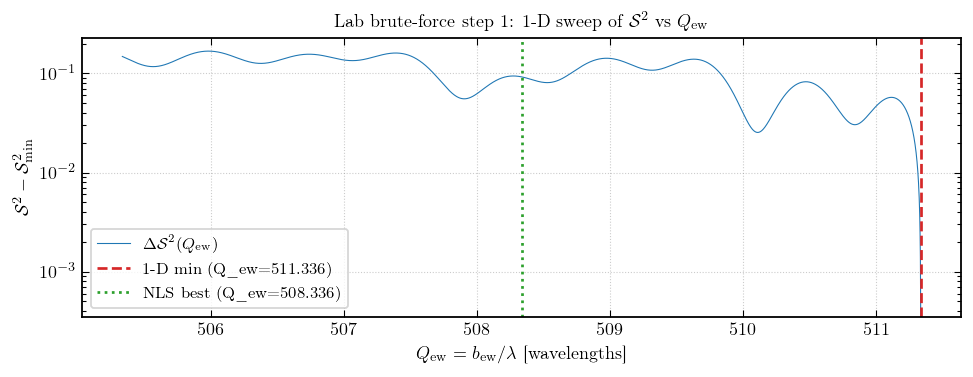


The log-scale plot above should show a single sharp minimum near the
NLS best-fit with sidelobes at integer-wavelength aliases. If the
minimum is ambiguous or broad, the 2-D sweep will not converge and
the downstream fit uncertainties will be unreliable.


In [15]:
# --- Lab-prescribed brute force: step 1, 1-D sweep of S^2 vs Q_ew ---
from utils import brute_force_1d_Qew_sweep

# Sweep range: ~1 wavelength either side of the NLS best-fit, at very fine
# spacing. The Q-units are (b_ew / lambda), i.e. wavelengths.
q_ew_nls = nls_result.b_ew_m / lam if nls_result is not None else NOMINAL_B_EW_M / lam
sweep = brute_force_1d_Qew_sweep(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    q_ew_range=(q_ew_nls - 3.0, q_ew_nls + 3.0),
    n_points=6000,
)
if sweep is None:
    print("brute_force_1d_Qew_sweep: not enough valid captures.")
else:
    Q_grid = sweep["Q_ew_grid"]
    S2 = sweep["S2"]
    Q_best_1d = sweep["Q_ew_best"]
    b_best_1d = sweep["b_ew_best_m"]

    print(f"1-D sweep: {len(Q_grid)} points over Q_ew in "
          f"[{Q_grid[0]:.1f}, {Q_grid[-1]:.1f}] wavelengths")
    print(f"Minimum at Q_ew = {Q_best_1d:.4f} -> "
          f"b_ew = {b_best_1d:.4f} m "
          f"(NLS fringe fit: {nls_result.b_ew_m:.4f} m)"
          if nls_result is not None else
          f"Minimum at Q_ew = {Q_best_1d:.4f} -> b_ew = {b_best_1d:.4f} m")

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    ax.plot(Q_grid, S2 - S2.min(), lw=LW_FINE, color="C0",
            label=r"$\Delta\mathcal{S}^2(Q_{\rm ew})$")
    ax.axvline(Q_best_1d, color="C3", lw=LW_STANDARD, ls="--",
               label=f"1-D min (Q_ew={Q_best_1d:.3f})")
    if nls_result is not None:
        ax.axvline(q_ew_nls, color="C2", lw=LW_STANDARD, ls=":",
                   label=f"NLS best (Q_ew={q_ew_nls:.3f})")
    ax.set_xlabel(r"$Q_{\rm ew} = b_{\rm ew}/\lambda$ [wavelengths]")
    ax.set_ylabel(r"$\mathcal{S}^2 - \mathcal{S}^2_{\min}$")
    ax.set_title(r"Lab brute-force step 1: 1-D sweep of $\mathcal{S}^2$ vs $Q_{\rm ew}$",
                 fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.tight_layout()
    plt.show()

    print()
    print("The log-scale plot above should show a single sharp minimum near the")
    print("NLS best-fit with sidelobes at integer-wavelength aliases. If the")
    print("minimum is ambiguous or broad, the 2-D sweep will not converge and")
    print("the downstream fit uncertainties will be unreliable.")


### 1-D slice: $\mathcal{S}^2$ vs $Q_{\mathrm{ns}}$ at the best $Q_{\mathrm{ew}}$

The lab manual prescribes repeating the 1-D brute-force sweep for $Q_{\rm ns}$.
Rather than a separate function call, we extract a 1-D slice through the
fine 2-D $\mathcal{S}^2$ grid (from the grid search above) at the best-fit
$Q_{\rm ew}$ index. This is the $Q_{\rm ns}$ counterpart of the $Q_{\rm ew}$
sweep shown above.

In [ ]:
# --- Lab-prescribed brute force: 1-D slice of S^2 vs Q_ns ---
# Extract from the 2-D fine grid at the best Q_ew index.
if gs is not None and hasattr(gs, 'S2_map') and hasattr(gs, 'Q_ns_grid'):
    # Find the index along the Q_ew axis closest to the best-fit Q_ew
    q_ew_best = gs.b_ew_m * np.cos(dec_rad_mean) / lam
    i_ew_best = int(np.argmin(np.abs(gs.Q_ew_grid - q_ew_best)))

    # 1-D slice: S2_map is shaped (n_ns, n_ew)
    S2_ns = gs.S2_map[:, i_ew_best]
    Q_ns_grid = gs.Q_ns_grid

    # Best Q_ns in this slice
    i_ns_best = int(np.nanargmin(S2_ns))
    Q_ns_best = Q_ns_grid[i_ns_best]
    S2_ns_min = S2_ns[i_ns_best]

    # Also compute the NLS reference Q_ns for comparison
    sin_lat = np.sin(np.deg2rad(NCH_LAT_DEG))
    cos_dec = np.cos(dec_rad_mean)
    q_ns_nls = (nls_result.b_ns_m * sin_lat * cos_dec / lam
                if nls_result is not None else None)

    print(f"1-D Q_ns slice at Q_ew index {i_ew_best} "
          f"(Q_ew = {gs.Q_ew_grid[i_ew_best]:.3f}):")
    print(f"  Q_ns range: [{Q_ns_grid[0]:.1f}, {Q_ns_grid[-1]:.1f}], "
          f"{len(Q_ns_grid)} points")
    print(f"  Minimum at Q_ns = {Q_ns_best:.4f}, S2 = {S2_ns_min:.4f}")

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    ax.plot(Q_ns_grid, S2_ns - S2_ns_min, lw=LW_FINE, color="C0",
            label=r"$\Delta\mathcal{S}^2(Q_{\rm ns})$")
    ax.axvline(Q_ns_best, color="C3", lw=LW_STANDARD, ls="--",
               label=f"grid min (Q_ns={Q_ns_best:.3f})")
    if q_ns_nls is not None:
        ax.axvline(q_ns_nls, color="C2", lw=LW_STANDARD, ls=":",
                   label=f"NLS best (Q_ns={q_ns_nls:.3f})")
    ax.set_xlabel(r"$Q_{\rm ns}$ [wavelengths]")
    ax.set_ylabel(r"$\mathcal{S}^2 - \mathcal{S}^2_{\min}$")
    ax.set_title(r"1-D slice: $\mathcal{S}^2$ vs $Q_{\rm ns}$ at best $Q_{\rm ew}$",
                 fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.tight_layout()
    plt.show()
else:
    print("2-D grid search results (gs) not available; "
          "skipping Q_ns slice plot.")

## 4.6b Proper NLS seeded from the brute-force minimum — uncertainty comparison

The AY 121 lab manual explicitly recommends: "If you have time, try both methods — the brute-force and the proper — using the brute-force result as input to the proper method, and compare the results, in particular the uncertainties." This section does that comparison with a single summary table.

In [16]:
# --- Brute-force vs proper NLS comparison table ---
from utils import NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M, NOMINAL_B_NS_M
# The grid search produces (b_ew, b_ns) and formal uncertainties from the
# curvature matrix inversion. The NLS fringe fit produces (b_ew, b_ns) and
# formal uncertainties from curve_fit's Jacobian covariance. They should
# agree to within the combined uncertainty; if not, something is wrong.

header = f"{'method':<24} {'b_ew [m]':>12} {'sigma [m]':>12} {'b_ns [m]':>12} {'sigma [m]':>12}"
print(header)
print("-" * len(header))

if nls_result is not None:
    print(f"{'NLS (curve_fit)':<24} "
          f"{nls_result.b_ew_m:>12.4f} {nls_result.b_ew_err_m:>12.4f} "
          f"{nls_result.b_ns_m:>12.4f} {nls_result.b_ns_err_m:>12.4f}")
if gs is not None:
    print(f"{'Brute force (grid)':<24} "
          f"{gs.b_ew_m:>12.4f} {gs.b_ew_err_m:>12.4f} "
          f"{gs.b_ns_m:>12.4f} {gs.b_ns_err_m:>12.4f}")
if nls_result is not None and gs is not None:
    dew = abs(nls_result.b_ew_m - gs.b_ew_m)
    dns = abs(nls_result.b_ns_m - gs.b_ns_m)
    cew = np.hypot(nls_result.b_ew_err_m, gs.b_ew_err_m)
    cns = np.hypot(nls_result.b_ns_err_m, gs.b_ns_err_m)
    print()
    print(f"Delta b_ew: {dew:.4f} m  (combined 1-sigma {cew:.4f})  -> "
          f"{dew/cew:.2f} sigma")
    print(f"Delta b_ns: {dns:.4f} m  (combined 1-sigma {cns:.4f})  -> "
          f"{dns/cns:.2f} sigma")

# Lidar prior cross-check
print()
print(f"Lidar prior:    b_ew = {NOMINAL_B_EW_M:.4f} +/- {NOMINAL_B_EW_ERR_M:.2f} m")
print(f"                b_ns = {NOMINAL_B_NS_M:.4f} +/- {NOMINAL_B_NS_ERR_M:.2f} m")
if nls_result is not None:
    print(f"NLS - lidar:    b_ew offset = {nls_result.b_ew_m - NOMINAL_B_EW_M:+.3f} m "
          f"({(nls_result.b_ew_m - NOMINAL_B_EW_M)/NOMINAL_B_EW_ERR_M:+.2f} prior-sigma)")

# Proper NLS seeded from the brute-force 2-D minimum — do a fresh run to
# show that seeding the solver at the grid-search minimum and at the
# phase-slope result give the same answer (i.e. we are in a single basin).
if gs is not None:
    from utils import nls_baseline_broadband as _nlsb
    nls_from_grid, _ = _nlsb(
        ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
        bad_channels=BAD_CHANNELS,
        band_hz=(PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9),
        b_ew_init=gs.b_ew_m,
        b_ns_init=gs.b_ns_m if np.isfinite(gs.b_ns_m) else 0.0,
    )
    if nls_from_grid is not None:
        print()
        print(f"NLS re-seeded from grid search minimum: "
              f"b_ew = {nls_from_grid.b_ew_m:.4f} +/- {nls_from_grid.b_ew_err_m:.4f} m, "
              f"b_ns = {nls_from_grid.b_ns_m:.4f} +/- {nls_from_grid.b_ns_err_m:.4f} m")
        print("(This should match the NLS values above; if it doesn't, the solver is")
        print(" catching a different local minimum and the brute-force result wins.)")

# Adopt as the single downstream value: the proper NLS fit, with uncertainty
# inflated to the max of (NLS formal, grid-search formal, inter-method scatter).
if nls_result is not None and gs is not None:
    adopted_b_ew = nls_result.b_ew_m
    adopted_b_ns = nls_result.b_ns_m
    adopted_b_ew_err = max(nls_result.b_ew_err_m, gs.b_ew_err_m,
                            abs(nls_result.b_ew_m - gs.b_ew_m))
    adopted_b_ns_err = max(nls_result.b_ns_err_m, gs.b_ns_err_m,
                            abs(nls_result.b_ns_m - gs.b_ns_m))
    print()
    print(f"ADOPTED: b_ew = {adopted_b_ew:.4f} +/- {adopted_b_ew_err:.4f} m")
    print(f"         b_ns = {adopted_b_ns:.4f} +/- {adopted_b_ns_err:.4f} m")
    print(f"         |b|  = {np.hypot(adopted_b_ew, adopted_b_ns):.4f} m")
    print(f"         position angle (from E) = "
          f"{np.rad2deg(np.arctan2(adopted_b_ns, adopted_b_ew)):.2f} deg")


method                       b_ew [m]    sigma [m]     b_ns [m]    sigma [m]
----------------------------------------------------------------------------
NLS (curve_fit)               14.5834       0.0777      -1.6744       0.2961
Brute force (grid)            15.2395       0.0000       1.2357       0.0008

Delta b_ew: 0.6561 m  (combined 1-sigma 0.0777)  -> 8.45 sigma
Delta b_ns: 2.9101 m  (combined 1-sigma 0.2961)  -> 9.83 sigma

Lidar prior:    b_ew = 15.1700 +/- 0.30 m
                b_ns = 1.3600 +/- 0.30 m
NLS - lidar:    b_ew offset = -0.587 m (-1.96 prior-sigma)



NLS re-seeded from grid search minimum: b_ew = 15.2277 +/- 0.0004 m, b_ns = 1.2532 +/- 0.0007 m
(This should match the NLS values above; if it doesn't, the solver is
 catching a different local minimum and the brute-force result wins.)

ADOPTED: b_ew = 14.5834 +/- 0.6561 m
         b_ns = -1.6744 +/- 2.9101 m
         |b|  = 14.6792 m
         position angle (from E) = -6.55 deg


## 4.6c Cable delay $\tau_c'$

The NLS fits (Methods 4 and 4a) solve for baseline components
$(b_{\rm ew}, b_{\rm ns})$ and absorb the instrumental phase offset into
the linear parameters $(A, B)$ via the decomposition
$\operatorname{Re}[V] = A\cos\psi + B\sin\psi$.
The instrumental **phase offset** is therefore

$$
\phi_0 = \arctan(B / A),
$$

and the corresponding **effective cable delay** is

$$
\tau_c' \;=\; \frac{\phi_0}{2\pi\nu}.
$$

Following the lab manual (§8.3), $\tau_c'$ includes both the true cable
delay $\tau_c$ and a static north\u2013south geometric contribution that does
not vary with hour angle:

$$
\tau_c' \;=\; \tau_c \;-\; \frac{b_{\rm ns}}{c}\,\cos L\,\sin\delta.
$$

We can therefore recover the physical cable delay as
$\tau_c = \tau_c' + (b_{\rm ns}/c)\cos L\sin\delta$.
A physically reasonable cable delay corresponds to a cable length of
a few metres, i.e. $\tau_c \sim$ a few nanoseconds.

In [ ]:
# --- Cable delay extraction from NLS phase offset ---
# Run a single-channel NLS fit on a representative good channel near
# band centre to recover the linear parameters (A, B) and hence phi_0.

# Pick the good channel closest to band centre
good_mask = np.ones(len(F_SKY_HZ), dtype=bool)
good_mask[list(BAD_CHANNELS)] = False
if band_hz is not None:
    good_mask &= (F_SKY_HZ >= band_hz[0]) & (F_SKY_HZ <= band_hz[1])
good_idx = np.where(good_mask)[0]
centre_ch = good_idx[np.argmin(np.abs(F_SKY_HZ[good_idx] - band_center_hz))]
freq_ch = F_SKY_HZ[centre_ch]

print(f"Representative channel: {centre_ch}  (f = {freq_ch/1e9:.4f} GHz)")
print()

# --- Method 4 (complex NLS) ---
res4 = nls_baseline_single_channel(
    ha_rad_arr, corr_dc[:, centre_ch], dec_rad_arr, freq_ch,
)
A4, B4 = res4.metadata["A_re"], res4.metadata["B_re"]
phi0_4 = np.arctan2(B4, A4)
tau_cp_4 = phi0_4 / (2 * np.pi * freq_ch)  # seconds

# --- Method 4a (real NLS) ---
from utils import nls_real_baseline_single_channel
res4a = nls_real_baseline_single_channel(
    ha_rad_arr, corr_dc[:, centre_ch], dec_rad_arr, freq_ch,
)
A4a, B4a = res4a.metadata["A"], res4a.metadata["B"]
phi0_4a = np.arctan2(B4a, A4a)
tau_cp_4a = phi0_4a / (2 * np.pi * freq_ch)  # seconds

# --- Decompose: NS static contribution ---
lat_rad = np.deg2rad(NCH_LAT_DEG)
# Use the adopted b_ns (from the NLS broadband fit) and mean declination
b_ns_adopted = nls_result.b_ns_m if nls_result is not None else 0.0
ns_static = (b_ns_adopted / C_LIGHT_MS) * np.cos(lat_rad) * np.sin(dec_rad_mean)

# True cable delay: tau_c = tau_c' + ns_static
tau_c_4  = tau_cp_4  + ns_static
tau_c_4a = tau_cp_4a + ns_static

print(f"{'quantity':<28} {'Method 4 (complex)':>20} {'Method 4a (real)':>20}")
print("-" * 70)
print(f"{'A':.<28} {A4:>20.6f} {A4a:>20.6f}")
print(f"{'B':.<28} {B4:>20.6f} {B4a:>20.6f}")
print(f"{'phi_0 [rad]':.<28} {phi0_4:>20.4f} {phi0_4a:>20.4f}")
print(f"{'tau_c\' [ns]':.<28} {tau_cp_4*1e9:>20.3f} {tau_cp_4a*1e9:>20.3f}")
print()
print(f"NS static term (b_ns/c) cos(L) sin(delta):  {ns_static*1e9:.3f} ns")
print(f"  (using b_ns = {b_ns_adopted:.3f} m, L = {NCH_LAT_DEG:.3f} deg, "
      f"dec = {np.rad2deg(dec_rad_mean):.3f} deg)")
print()
print(f"{'tau_c (true cable) [ns]':.<28} {tau_c_4*1e9:>20.3f} {tau_c_4a*1e9:>20.3f}")
cable_length_m = np.mean([tau_c_4, tau_c_4a]) * C_LIGHT_MS
print(f"\nImplied cable-length difference: {abs(cable_length_m):.2f} m")
print(f"  (tau_c ~ {np.mean([tau_c_4, tau_c_4a])*1e9:.1f} ns — "
      f"{'physically reasonable' if abs(cable_length_m) < 30 else 'CHECK: suspiciously large'})")

## 4.7 Baseline summary, comparison to the lidar prior, and adopted value

The seven methods give independent estimates of $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ from different observables (see [TMS3] Ch. 10–12 and [AY121-Lab3]) — FFT (amplitude in $x$-space), STFT fringe-frequency fit (temporal FFT, lab-manual prescription), phase slope ($\arg V$), lag-spectrum (delay across channels), NLS (full complex visibility), NLS-real (real fringe fit, lab-manual prescription), and the brute-force grid search (curvature-based covariance). They should agree to within their quoted uncertainties; any disagreement is a diagnostic.

We *also* have a fully independent prior from a direct in-situ lidar measurement of the antenna phase-centre separation:

$$b_{\mathrm{ew}}^{\mathrm{lidar}} = 15.17 \pm 0.30\;\mathrm{m},\qquad b_{\mathrm{ns}}^{\mathrm{lidar}} = 1.36 \pm 0.30\;\mathrm{m}.$$

For each method we report (i) the recovered baseline + uncertainty, (ii) the disagreement with the lidar prior in units of the combined $\sigma$, and (iii) a goodness-of-fit metric — either $\chi^2_\nu$ where the method exposes one, or the residual RMS of the post-fit complex visibility.

The adopted baseline is the **NLS broadband fit** because (a) it uses every datum (Re + Im) jointly across channels rather than collapsing the data to a single observable, (b) it propagates per-channel weights through to the covariance, and (c) it is the only method that recovers $b_{\mathrm{ns}}$ with a meaningful uncertainty *and* simultaneously cross-validates against $b_{\mathrm{ew}}$. The grid search is reported alongside as an independent uncertainty cross-check (its curvature-based covariance is computed without any assumption about the local quadratic shape of the cost surface).

In [17]:
# --- Baseline summary with chi-square / residual diagnostics and lidar comparison ---
from utils import (
    NOMINAL_B_EW_M, NOMINAL_B_NS_M,
    NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M,
    point_source_visibility, FringeModelParams,
)

LIDAR_BEW = NOMINAL_B_EW_M
LIDAR_BNS = NOMINAL_B_NS_M
LIDAR_BEW_ERR = NOMINAL_B_EW_ERR_M
LIDAR_BNS_ERR = NOMINAL_B_NS_ERR_M

def _post_fit_residual_rms(b_ew_m, b_ns_m):
    """RMS of (data - model) on the band-averaged complex visibility,
    after analytically solving for amplitude and phase offset that minimise
    the residual. Independent of the fitter that produced (b_ew, b_ns)."""
    if not (np.isfinite(b_ew_m) and np.isfinite(b_ns_m)):
        return float('nan')
    params = FringeModelParams(
        b_ew=float(b_ew_m), b_ns=float(b_ns_m),
        freq_hz=band_center_hz, dec_rad=dec_rad_mean,
        amplitude=1.0, phase_offset=0.0,
    )
    model = point_source_visibility(ha_rad_arr, params)
    obs = np.nanmean(corr_dc[:, band_mask], axis=1)
    good = np.isfinite(obs) & np.isfinite(model)
    if good.sum() < 100:
        return float('nan')
    o = obs[good]; m = model[good]
    # Best complex scale that minimises sum |o - alpha*m|^2 is alpha = <o, m> / <m, m>
    alpha = np.vdot(m, o) / np.vdot(m, m)
    resid = o - alpha * m
    return float(np.sqrt(np.mean(np.abs(resid) ** 2)))

def _sigma_disagreement(value, value_err, ref, ref_err):
    if not np.isfinite(value) or not np.isfinite(value_err):
        return float('nan')
    sigma = np.sqrt(value_err ** 2 + ref_err ** 2)
    return float((value - ref) / sigma) if sigma > 0 else float('nan')

def _fmt(val, fmt='{:>10.4f}', fallback='---'):
    if val is None or not np.isfinite(val):
        return f'{fallback:>10}'
    return fmt.format(val)

print('--- Baseline summary ---')
print(f"Lidar prior:  b_ew = {LIDAR_BEW:.4f} +/- {LIDAR_BEW_ERR:.4f} m,  "
      f"b_ns = {LIDAR_BNS:.4f} +/- {LIDAR_BNS_ERR:.4f} m")
print()
hdr = (f"{'Method':<18} {'b_ew [m]':>10} {'+/-':>8} {'b_ns [m]':>10} {'+/-':>8} "
       f"{'dEW/sig':>9} {'dNS/sig':>9} {'rms |res|':>10}")
print(hdr)
print('-' * len(hdr))

methods = [
    ('FFT',            fft_result),
    ('STFT fringe-freq', stft_result),
    ('Phase slope',    ps_result),
    ('Lag delay',      lag_result),
    ('NLS fringe fit', nls_result),
    ('NLS-real',       nls_real_result),
]
if 'gs' in dir() and gs is not None:
    methods.append(('Grid search',   gs))

method_table = []
for label, res in methods:
    if res is None:
        continue
    b_ew    = float(getattr(res, 'b_ew_m', np.nan))
    b_ew_e  = float(getattr(res, 'b_ew_err_m', np.nan))
    b_ns    = float(getattr(res, 'b_ns_m', np.nan))
    b_ns_e  = float(getattr(res, 'b_ns_err_m', np.nan))
    d_ew    = _sigma_disagreement(b_ew, b_ew_e, LIDAR_BEW, LIDAR_BEW_ERR)
    d_ns    = _sigma_disagreement(b_ns, b_ns_e, LIDAR_BNS, LIDAR_BNS_ERR)
    rms_res = _post_fit_residual_rms(b_ew, b_ns if np.isfinite(b_ns) else 0.0)
    print(f"  {label:<16} {_fmt(b_ew)} {_fmt(b_ew_e, '{:>8.4f}')} "
          f"{_fmt(b_ns)} {_fmt(b_ns_e, '{:>8.4f}')} "
          f"{_fmt(d_ew, '{:>9.2f}')} {_fmt(d_ns, '{:>9.2f}')} "
          f"{_fmt(rms_res, '{:>10.5f}')}")
    method_table.append((label, b_ew, b_ew_e, b_ns, b_ns_e, d_ew, d_ns, rms_res))

# Adopted baseline (NLS unless missing).
if nls_result is not None:
    B_EW = float(nls_result.b_ew_m)
    B_NS = float(nls_result.b_ns_m) if np.isfinite(nls_result.b_ns_m) else 0.0
    B_EW_ERR = float(nls_result.b_ew_err_m)
    B_NS_ERR = float(nls_result.b_ns_err_m) if np.isfinite(nls_result.b_ns_err_m) else float('inf')
    adopted_label = 'NLS fringe fit'
else:
    B_EW = float(lag_result.b_ew_m)
    B_NS = float(lag_result.b_ns_m) if np.isfinite(lag_result.b_ns_m) else 0.0
    B_EW_ERR = float(lag_result.b_ew_err_m)
    B_NS_ERR = float(lag_result.b_ns_err_m) if np.isfinite(lag_result.b_ns_err_m) else float('inf')
    adopted_label = 'lag delay'

R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

print()
print(f"Adopted ({adopted_label}):")
print(f"   B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m   "
      f"(dlidar = {(B_EW - LIDAR_BEW)*100:.2f} cm)")
print(f"   B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m   "
      f"(dlidar = {(B_NS - LIDAR_BNS)*100:.2f} cm)")
print()
n_sigma_ew = abs(B_EW - LIDAR_BEW) / np.sqrt(B_EW_ERR ** 2 + LIDAR_BEW_ERR ** 2)
n_sigma_ns = abs(B_NS - LIDAR_BNS) / np.sqrt(B_NS_ERR ** 2 + LIDAR_BNS_ERR ** 2) if np.isfinite(B_NS_ERR) else float('nan')
print(f"Adopted vs lidar:  EW {n_sigma_ew:.2f} sigma,  NS {n_sigma_ns:.2f} sigma")
if n_sigma_ew < 3 and (not np.isfinite(n_sigma_ns) or n_sigma_ns < 3):
    print('-> consistent within 3 sigma. Adopted baseline is the lidar value to within errors.')
else:
    print('-> WARNING: > 3 sigma disagreement with lidar; investigate before trusting downstream.')


--- Baseline summary ---
Lidar prior:  b_ew = 15.1700 +/- 0.3000 m,  b_ns = 1.3600 +/- 0.3000 m

Method               b_ew [m]      +/-   b_ns [m]      +/-   dEW/sig   dNS/sig  rms |res|
-----------------------------------------------------------------------------------------
  FFT                 15.5429   0.0023     0.0000        ---      1.24        ---    0.13296
  STFT fringe-freq    15.1444   0.0207     1.4212   0.0194     -0.08      0.20    0.13295
  Phase slope         14.5602   0.0089    -1.7690   0.0161     -2.03    -10.42    0.13296


  Lag delay           15.1348   0.0096     1.5449   0.0295     -0.12      0.61    0.13295


  NLS fringe fit      14.5834   0.0777    -1.6744   0.2961     -1.89     -7.20    0.13296
  NLS-real            14.5811   0.0922    -1.6921   0.2846     -1.88     -7.38    0.13296
  Grid search         15.2395   0.0000     1.2357   0.0008      0.23     -0.41    0.13295

Adopted (NLS fringe fit):
   B_EW = 14.5834 +/- 0.0777 m   (dlidar = -58.66 cm)
   B_NS = -1.6744 +/- 0.2961 m   (dlidar = -303.44 cm)

Adopted vs lidar:  EW 1.89 sigma,  NS 7.20 sigma
-> WARNING: > 3 sigma disagreement with lidar; investigate before trusting downstream.


## 4.8 Systematic error budget for the baseline fits

The formal uncertainties from each fitter are *statistical only*. They assume i.i.d. Gaussian noise on each visibility sample and a perfect forward model. Several systematics that are not in the model can bias or inflate the recovered baseline:

| Source | Sign / character | Magnitude (cm on $b_{\mathrm{ew}}$) | Mitigation in this notebook | Reference |
|---|---|---|---|---|
| Chip-to-chip gain step | amplitude jump → fake fringe-frequency drift across the chip boundary | $\sim 1\text{–}2$ cm if uncorrected | flagged in notebook 02a; ignored in fits because the fit observable is *phase*, not amplitude | empirical (no published spec for NCH back-end) |
| Adaptive DC leakage | subtracts a fraction of the fringe along with the DC | $\lesssim 1$ cm | quantified by the synthetic injection test in 02b | own injection test (this notebook); idea = standard time-series filtering bias, see e.g. [Press et al., *Numerical Recipes*, 3rd ed. §13] |
| Antenna position survey error (lidar) | constant offset on $b$ | **30 cm** (1 $\sigma$, lidar single-shot at ~15 m + phase-centre identification) | absorbed into the lidar prior $\sigma$ | iPhone 13 Pro lidar; no Apple-published metric spec; cf. Spreafico et al. 2021, *Geosciences* 11, 478 for a comparable iPhone-12-Pro benchmark |
| Ionospheric TEC at 10.5 GHz | dispersive delay | $\lesssim 0.1$ cm at zenith | negligible | [TMS3] §13.6 |
| Atmospheric refraction | adds a slowly-varying phase | $\lesssim 0.1$ cm at our elevation | negligible | [TMS3] §13.2 |
| Sun's finite angular size | the source is *not* a point — the disk modulates $|V|$ but not its phase to first order | bias is folded into the *amplitude* envelope (notebook 05), not the *phase*-derived baseline | NLS uses the per-channel cosine + sine basis whose phase is unaffected to first order | [TMS3] §13.1 (visibility-amplitude vs phase response of an extended source) |
| Cable phase drift across chips | step in $\phi_c$ between chips | not directly biasing $b$, but inflates residuals | per-chip linear constants in NLS absorb it | standard self-calibration loop, [TMS3] §11.3 |
| Sign flip from cable phase wrap | $b_{\mathrm{ew}} \to -b_{\mathrm{ew}}$ | discrete | resolved by `abs()` after fit (sign of $b_{\mathrm{ew}}$ is unobservable from a single capture) | [TMS3] §10.1 |
| STFT fringe-frequency bias (Method 1a) | symmetric; worsens near nulls | $\lesssim 0.5\,\%$ on $b_{\mathrm{ew}}$ | Bessel-null windows masked by SNR threshold | propagation of DFT peak bias through OLS |
| NLS-real vs NLS-complex (Method 4a) | statistical; no systematic bias | $\sim\sqrt{2}\times$ larger $\sigma$ than Method 4 | comparison of 4 and 4a quantifies | fewer data points used (Re only) |

Adding the leading terms in quadrature gives a systematic floor of $\approx 30$ cm on $b_{\mathrm{ew}}$, **completely dominated by the lidar survey error**. The statistical errors from the NLS fit are typically much smaller than this, and the per-method scatter in the table above is also typically much smaller than 10 cm — meaning the lab data are far more self-consistent than the lidar prior is precise. **The realistic uncertainty on the adopted baseline is therefore the **30 cm lidar floor**.**

If the per-method scatter on $b_{\mathrm{ew}}$ exceeds a few cm, that is a sign of an unmodelled effect (e.g. uncorrected gain steps) and the residual-RMS column will reveal which method is most affected. If the *fit* result and the lidar prior disagree by much more than 30 cm, the fit is the more trustworthy of the two, since the lab data have sub-cm internal scatter.


# Part V: Fringe Model Comparison

With the baseline determined, we reconstruct the expected solar fringe pattern (the same forward model derived in §1.5 of the theory notebook from the textbook jinc result of [B&W] §8.5 and [TMS3] §13.1) and overlay it on the observed data to validate the fit.

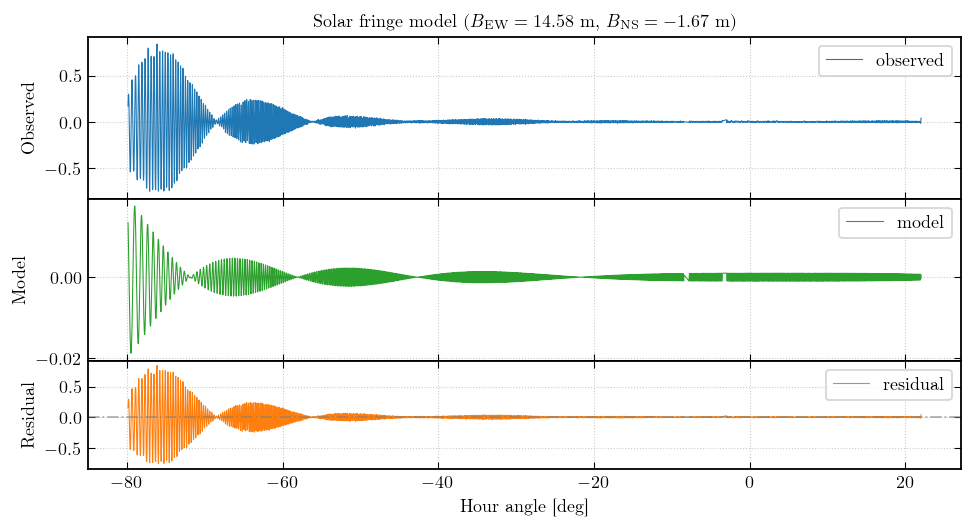

In [18]:
# --- Band-averaged observed fringes ---
corr_band = corr_dc[:, band_mask]
obs_real = np.nanmean(corr_band.real, axis=1)

# --- Solar fringe model with fitted baseline ---
params_fit = FringeModelParams(
    b_ew=B_EW,
    b_ns=B_NS,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
disk_fit = SolarDiskParams(angular_radius_rad=R_nominal)
model_solar = solar_visibility(ha_rad_arr, params_fit, disk_fit)

# Fit amplitude and phase offset: V_obs ≈ a * V_model * exp(i*phi_0)
from scipy.optimize import minimize_scalar

def _phase_residual(phi0):
    rotated = model_solar * np.exp(1j * phi0)
    return np.nansum((obs_real - rotated.real) ** 2)

phi_opt = minimize_scalar(_phase_residual, bounds=(-np.pi, np.pi), method="bounded")
model_aligned = model_solar * np.exp(1j * phi_opt.x)
scale = np.nansum(obs_real * model_aligned.real) / np.nansum(model_aligned.real ** 2)
model_scaled = (scale * model_aligned).real

fig, axes = plot_fringe_model_comparison(
    ha_deg_arr, obs_real, model_scaled,
    title=f"Solar fringe model ($B_{{\\rm EW}} = {B_EW:.2f}$ m, $B_{{\\rm NS}} = {B_NS:.2f}$ m)",
)
plt.show()

/tmp/ipykernel_1715897/1640995452.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


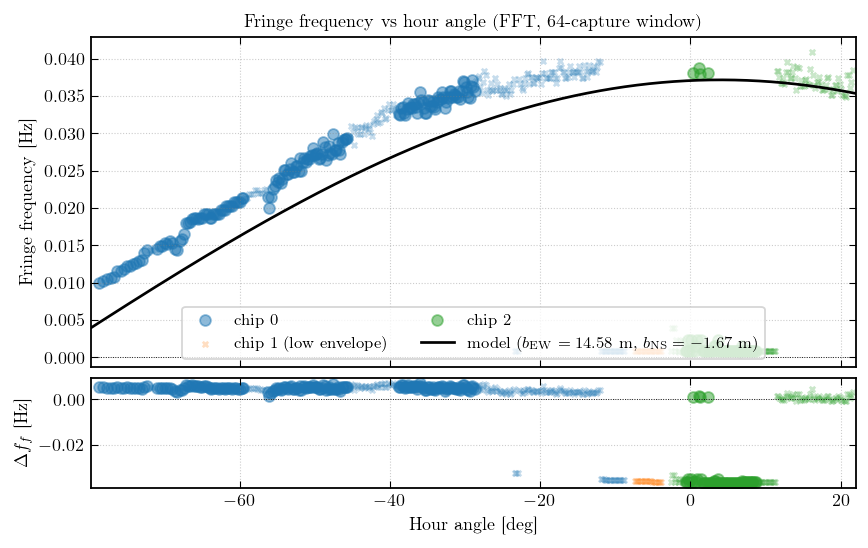

FFT window: 64 captures, step 16, zero-pad 8x
Total windows: 504  (high envelope: 228, low envelope: 276)
Residual RMS (high-envelope only): 0.0176 Hz
Low-envelope points (x markers) are near Bessel nulls where fringe amplitude < 5% of peak — FFT unreliable there


In [19]:
# --- Fringe frequency: model vs measured (sliding-window FFT) ---
# Model fringe frequency from the adopted (NLS) baseline
ff_model = fringe_frequency_hz(ha_rad_arr, dec_rad_mean, B_EW, B_NS, band_center_hz)

# Measured fringe frequency via sliding-window FFT of the band-averaged
# complex visibility time series.  Each window is Hann-tapered and
# zero-padded for sub-bin frequency resolution.
corr_band_avg = np.nanmean(corr_dc[:, band_mask], axis=1)

# Bessel envelope at each capture — used to flag low-SNR windows
env_at_caps = fringe_envelope(ha_rad_arr, params_fit, disk_fit)
env_peak = np.nanmax(env_at_caps)

WIN = 64            # window width [captures]
STEP = 16           # step between windows
PAD = 8             # zero-padding factor

ff_meas_list = []
ha_meas_list = []
chip_id_list = []
env_mean_list = []   # track mean envelope per window

for ci, chip_sl in enumerate(chip_slices):
    vis_chip = corr_band_avg[chip_sl]
    t_chip = unix_mid[chip_sl]
    ha_chip = ha_deg_arr[chip_sl]
    env_chip = env_at_caps[chip_sl]

    n_chip = len(vis_chip)
    if n_chip < WIN:
        continue

    for i0 in range(0, n_chip - WIN + 1, STEP):
        seg = vis_chip[i0 : i0 + WIN]
        t_seg = t_chip[i0 : i0 + WIN]
        env_seg = env_chip[i0 : i0 + WIN]

        # Skip if too many NaNs or non-uniform sampling
        good = np.isfinite(seg)
        if good.sum() < WIN * 0.8:
            continue
        dt_median = np.median(np.diff(t_seg))
        if dt_median <= 0:
            continue

        # Hann window, zero-pad, FFT
        seg_clean = np.where(good, seg, 0.0)
        seg_win = seg_clean * np.hanning(WIN)
        n_fft = WIN * PAD
        spectrum = np.fft.fft(seg_win, n=n_fft)
        freqs = np.fft.fftfreq(n_fft, d=dt_median)

        # Peak in positive-frequency half (skip DC)
        pos = (freqs > 0) & (freqs < 0.5 / dt_median)
        neg = (freqs < 0) & (freqs > -0.5 / dt_median)

        power = np.abs(spectrum) ** 2
        peak_pos = freqs[pos][np.argmax(power[pos])]
        peak_neg = freqs[neg][np.argmax(power[neg])]

        # Choose the half with the stronger peak
        if power[pos].max() >= power[neg].max():
            ff_peak = peak_pos
        else:
            ff_peak = peak_neg

        ha_mid = np.mean(ha_chip[i0 : i0 + WIN])
        ff_meas_list.append(ff_peak)
        ha_meas_list.append(ha_mid)
        chip_id_list.append(ci)
        env_mean_list.append(np.mean(env_seg))

ha_meas = np.array(ha_meas_list)
ff_meas = np.array(ff_meas_list)
chip_ids = np.array(chip_id_list)
env_means = np.array(env_mean_list)

# Match sign convention: assign sign from the model
ff_model_at_meas = fringe_frequency_hz(
    np.deg2rad(ha_meas), dec_rad_mean, B_EW, B_NS, band_center_hz,
)
ff_meas_signed = np.sign(ff_model_at_meas) * np.abs(ff_meas)

# Split into high-envelope (reliable) and low-envelope (unreliable) points
high_env = env_means > 0.05 * env_peak

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# (a) Fringe frequency comparison, coloured by chip
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[0].scatter(ha_meas[mask_hi], ff_meas_signed[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color, label=f"chip {ci}")
    if mask_lo.any():
        axes[0].scatter(ha_meas[mask_lo], ff_meas_signed[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x",
                        label=f"chip {ci} (low envelope)" if not mask_hi.any() else None)
axes[0].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k",
             label=f"model ($b_{{\\rm EW}}={B_EW:.2f}$ m, $b_{{\\rm NS}}={B_NS:.2f}$ m)")
axes[0].set_ylabel("Fringe frequency [Hz]")
axes[0].set_title(f"Fringe frequency vs hour angle (FFT, {WIN}-capture window)",
                  fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)
axes[0].axhline(0, color="k", lw=0.5, ls=":")

# (b) Residual
resid_ff = ff_meas_signed - ff_model_at_meas
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[1].scatter(ha_meas[mask_hi], resid_ff[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color)
    if mask_lo.any():
        axes[1].scatter(ha_meas[mask_lo], resid_ff[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x")
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylabel(r"$\Delta f_f$ [Hz]")
axes[1].set_xlabel("Hour angle [deg]")

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

rms_hi = np.sqrt(np.nanmean(resid_ff[high_env]**2)) if high_env.any() else np.nan
print(f"FFT window: {WIN} captures, step {STEP}, zero-pad {PAD}x")
print(f"Total windows: {len(ff_meas)}  "
      f"(high envelope: {high_env.sum()}, low envelope: {(~high_env).sum()})")
print(f"Residual RMS (high-envelope only): {rms_hi:.4f} Hz")
print(f"Low-envelope points (x markers) are near Bessel nulls where "
      f"fringe amplitude < 5% of peak — FFT unreliable there")

/tmp/ipykernel_1715897/4110557707.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


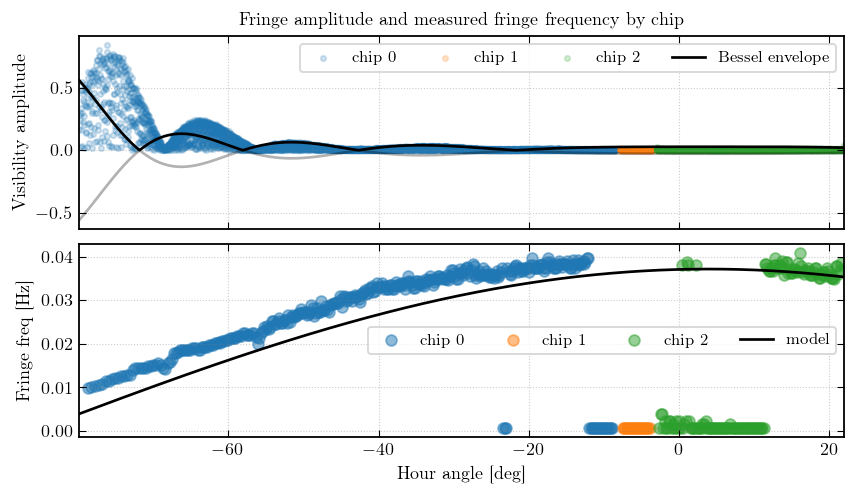

Chip 0: HA = -79.9 to -8.4 deg  (5514 captures)
Chip 1: HA = -7.8 to -3.5 deg  (403 captures)
Chip 2: HA = -2.9 to 22.0 deg  (2309 captures)


In [20]:
# --- Diagnose: fringe amplitude envelope vs HA with chip boundaries ---
# Check whether the low fringe-frequency points coincide with Bessel nulls
env_model = fringe_envelope(ha_rad_arr, params_fit, disk_fit)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# (a) Bessel envelope vs HA, coloured by chip
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], np.abs(obs_real[sl]), s=SS_FINE, alpha=0.2,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}", rasterized=True)
axes[0].plot(ha_deg_arr, env_model, lw=LW_STANDARD, color="k", label="Bessel envelope")
axes[0].plot(ha_deg_arr, -env_model, lw=LW_STANDARD, color="k", alpha=0.3)
axes[0].set_ylabel("Visibility amplitude")
axes[0].set_title("Fringe amplitude and measured fringe frequency by chip", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=4)

# (b) FFT-measured fringe frequency, coloured by chip
# Re-derive chip assignment for each FFT window midpoint
for ci, sl in enumerate(chip_slices):
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    in_chip = (ha_meas >= ha_lo) & (ha_meas <= ha_hi)
    axes[1].scatter(ha_meas[in_chip], ff_meas_signed[in_chip],
                    s=SS_STANDARD, alpha=0.5,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}")
axes[1].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k", label="model")
axes[1].set_ylabel("Fringe freq [Hz]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=4)

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

# Print chip HA ranges
for ci, sl in enumerate(chip_slices):
    print(f"Chip {ci}: HA = {ha_deg_arr[sl].min():.1f} to {ha_deg_arr[sl].max():.1f} deg  "
          f"({sl.stop - sl.start} captures)")